In [11]:
import os
from dotenv import load_dotenv
from langchain_anthropic import ChatAnthropic
from langchain_tavily import TavilySearch
load_dotenv()

True

In [ ]:
api_key = os.getenv("claudeAPI")

llm = ChatAnthropic(
    model = "claude-haiku-4-5-20251001",
    api_key= api_key
)

In [ ]:
tavily_tool = TavilySearch(
       tavily_api_key=os.getenv("tavilyAPI"),  
       max_results=5
   )

In [ ]:
from typing import Annotated, List
from langchain_tavily import TavilySearch
from langchain_core.tools import StructuredTool
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader



from langgraph.graph import StateGraph, START, END

In [22]:
Embeddings = HuggingFaceEmbeddings(
    model_name  = "sentence-transformers/all-MiniLM-L6-v2"
)

In [ ]:
def make_retriever_tool_from_text(file, name, desc) :
    docs = TextLoader(file, encoding= "utf-8").load()
    chunks = RecursiveCharacterTextSplitter(chunk_size = 500, chunk_overlap = 50).split_documents(docs)
    vs  = FAISS.from_documents(chunks, Embeddings)
    retriever = vs.as_retriever()

    
    def tool_func(query : str) -> str :
        print(f"Using tool : {name}")
        result = retriever.invoke(query)
        return "\n\n".join(doc.page_content for doc in result)

    return StructuredTool.from_function( name = name, description= desc, func = tool_func)



internal_tool_1 = make_retriever_tool_from_text("/Users/akashdeepsangwan/Desktop/Code/GenAI/AgenticAI/MultiAgentRAG/research_notes.txt",
                                                "retriever tool", "retrieves the document"
                                            )
internal_tool_1


StructuredTool(name='retriever tool', description='retrieves the document', args_schema=<class 'langchain_core.utils.pydantic.retriever tool'>, func=<function make_retriever_tool_from_text.<locals>.tool_func at 0x1254eefc0>)

### Command
- In langraph it is used for dynamic routing and controlling which node runs next.
- It replaces fixed edges with runtime decisions

-- it let next node to run or (END)

In [32]:
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.prebuilt import create_react_agent
from langgraph.graph import MessagesState, END
from langgraph.types import Command

def get_next_node(last_message : BaseMessage, goto : str) :
    if "FINAL ANSWER" in last_message.content  :
        # Any agent decided the work is done
        return END
    return goto


In [31]:
def make_system_prompt(suffix : str) -> str :
    return(
        "You are a helpful AI assistant, collaborating with other assistants."
        "Use the provided tools to progress towards answering the question"
        "If you are unable to fully answer, that's OK, use another assistant with different tools"
        "Will help where you left off. Execute where you can to make progress."
        "If you or nay of the other assitants have the final answer or deliverable"
        "prefix you response with FINAL ANSWER so the team knows to stop"
        f"\n{suffix}"
    )

/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_42861/1226982586.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


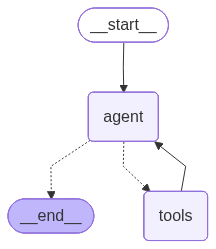

In [ ]:
## Research Agent and Node
research_agent = create_react_agent(
    llm,
    tools = [internal_tool_1, tavily_tool],
    prompt = make_system_prompt("You can only do research. Use the tool that you are binded with, you can use both of them")
)

research_agent

In [48]:
from typing import Literal
## Research Node
def research_node(state : MessagesState) -> Command[Literal['blog_generator', END]] :

    result = research_agent.invoke(state)
    goto  = get_next_node(result["messages"][-1], "blog_generator")
    
    result['messages'][-1] = HumanMessage(
        content = result["messages"][-1].content, name = "researcher"
    )

    return Command(
        update = {
            "messages" : result['messages']
        }, goto=goto,
    )
    

In [ ]:
# Blog write agent
blog_agent = create_react_agent(
    llm, tools = [tavily_tool],
    prompt = make_system_prompt("You can only write a detailed blog. You are working with a researcher colleague.")

)


def blog_node(state : MessagesState) -> Command[Literal['researcher', END]] :
    result = blog_agent.invoke(state)
    goto= get_next_node(result["messages"][-1], "researcher")

    result['messages'][-1] = HumanMessage(
        content = result['messages'][-1].content, name = "blog_generator"
    )
    
    return Command(
        update = {
            "messages" : result["messages"]
        }, goto = goto
    )


/var/folders/58/7rk_l2gn3lv73f_nlj98yjgc0000gn/T/ipykernel_42861/3647684055.py:6: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  blog_agent = create_react_agent(


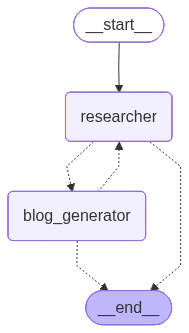

In [49]:
workflow = StateGraph(MessagesState)
workflow.add_node("researcher", research_node)
workflow.add_node("blog_generator", blog_node)

workflow.add_edge(START, "researcher")
graph = workflow.compile()
graph

In [ ]:
graph.invoke({"messages": "Write a detailed blog on tranformer varient in production deployments"})